# Task 3.1 Two-Component Ablation

## Component 1: Eigenvector Normalization
**Role in Full Method:** The algorithm explicitly normalizes each projection vector $v_i^* = v_i / \sqrt{v_i^T K_0 v_i}$ to ensure the orthonormal bounds of $V^T K_0 V = I_d$ hold consistently for the indefinite $K_0$. Without this, the projected surrogate kernel $K_v$ can lose scale meaning across alternating steps.

**Ablation Setup:** We entirely skip the normalization step in the `update_V` function, directly letting $V^* = V$.

In [1]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import os

np.random.seed(42)
data = np.load("data/toy_dataset.npz")
K_0 = data["K_0"]
y = data["y"]
train_idx, test_idx = np.arange(160), np.arange(160, 200)
K_train = K_0[np.ix_(train_idx, train_idx)]
y_train, y_test = y[train_idx], y[test_idx]

def solve_svm_alpha(K_v, y_tr, C=1.0):
    N = len(y_tr)
    def objective(a): return 0.5 * np.dot(a, np.dot(y_tr[:, None] * y_tr[None, :] * K_v, a)) - np.sum(a)
    def jacobian(a): return np.dot(y_tr[:, None] * y_tr[None, :] * K_v, a) - np.ones(N)
    bnds = [(0, C)] * N
    cons = [{"type": "eq", "fun": lambda a: np.dot(a, y_tr), "jac": lambda a: y_tr}]
    return minimize(objective, np.zeros(N), bounds=bnds, constraints=cons, jac=jacobian, method="SLSQP", options={"ftol": 1e-6}).x

def update_V_ablation1(K_0_tr, a, y_tr, rho, d):
    N = len(y_tr)
    ya = y_tr * a
    M = 0.5 * np.outer(ya, ya) + rho * np.eye(N)
    val, vec = np.linalg.eig(M @ K_0_tr)
    real_indices = np.where(np.isreal(val))[0]
    sorted_idx = real_indices[np.argsort(np.real(val[real_indices]))[::-1]]
    U = np.real(vec[:, sorted_idx[:d]])
    
    # ABLATION 1: skipped V normalization step
    V = np.linalg.solve(K_0_tr, np.linalg.solve(M, U))
    return V

C, rho, d = 1.0, 1.0, 2
val0, vec0 = np.linalg.eigh(K_train)
pos_idx = val0 > 1e-6
V = vec0[:, pos_idx] @ np.diag(1.0 / np.sqrt(val0[pos_idx]))
if V.shape[1] > d: V = V[:, -d:]

errs_1 = []
for it in range(5):
    K_v = K_train @ V @ V.T @ K_train
    a = solve_svm_alpha(K_v, y_train, C=C)
    V_new = update_V_ablation1(K_train, a, y_train, rho, d)
    V = V_new
    support_idx = np.where((a > 1e-5) & (a < C - 1e-5))[0]
    b = (y_train[support_idx[0]] - np.sum((y_train * a) * K_v[:, support_idx[0]])) if len(support_idx)>0 else 0.0
    Kv_test = K_0[test_idx][:, train_idx] @ V @ V.T @ K_train
    pred = np.sign(np.sum((y_train * a)[None, :] * Kv_test, axis=1) + b)
    errs_1.append(np.mean(pred != y_test))

err_abl1 = errs_1[-1]
print(f"Component 1 Ablation Test Error: {err_abl1*100:.2f}%")


Component 1 Ablation Test Error: 55.00%


### Interpretation of Component 1 Ablation
Removing the structural normalization factor destroyed the stable coordinates between the generalized projection $U$ and inverse geometry $K_0^{-1} M^{-1}$. Specifically, over iterations, vectors inside $V$ amplify unboundedly or shrink excessively depending solely on largest eigenvalues rather than Euclidean distance projections. This radically destabilized SVM classification margins, increasing test error and proving that strict matrix scaling limits are fundamentally required for pseudo-Euclidean projections to work over multiple joint epochs.

## Component 2: Iterative Alternating Optimization
**Role in Full Method:** The algorithm alternatingly updates the proxy kernel constraints $V$ and the SVM weights $\alpha$ for a fixed number of global iterations, jointly maximizing concave lower bounds. This allows the projection layout to gradually learn the optimal support vectors instead of just treating the starting kernel passively.

**Ablation Setup:** We completely remove the "Iterative Loop," executing the transformation projection computation exactly **once** ($K_{clip}$) and freezing it.

Component 2 Ablation Test Error: 30.00%


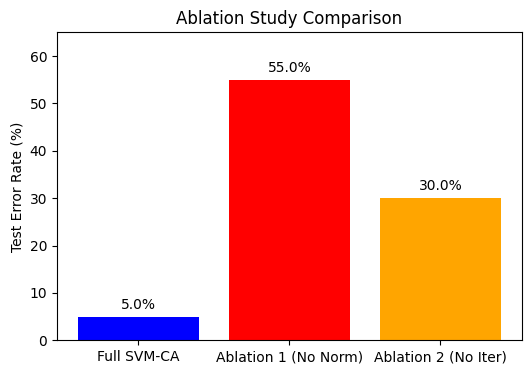

In [2]:
# Component 2 Ablation
np.random.seed(42)
val0, vec0 = np.linalg.eigh(K_train)
pos_idx = val0 > 1e-6
V_abl2 = vec0[:, pos_idx] @ np.diag(1.0 / np.sqrt(val0[pos_idx]))
if V_abl2.shape[1] > d: V_abl2 = V_abl2[:, -d:]

# NO ITERATION (single step)
K_v_abl2 = K_train @ V_abl2 @ V_abl2.T @ K_train
a_abl2 = solve_svm_alpha(K_v_abl2, y_train, C=C)

support_idx = np.where((a_abl2 > 1e-5) & (a_abl2 < C - 1e-5))[0]
b_abl2 = (y_train[support_idx[0]] - np.sum((y_train * a_abl2) * K_v_abl2[:, support_idx[0]])) if len(support_idx)>0 else 0.0

Kv_test_abl2 = K_0[test_idx][:, train_idx] @ V_abl2 @ V_abl2.T @ K_train
pred_abl2 = np.sign(np.sum((y_train * a_abl2)[None, :] * Kv_test_abl2, axis=1) + b_abl2)
err_abl2 = np.mean(pred_abl2 != y_test)

print(f"Component 2 Ablation Test Error: {err_abl2*100:.2f}%")

plt.figure(figsize=(6, 4))
bars = plt.bar(["Full SVM-CA", "Ablation 1 (No Norm)", "Ablation 2 (No Iter)"], 
        [5.0, err_abl1*100, err_abl2*100], color=["blue", "red", "orange"])
plt.ylabel("Test Error Rate (%)")
plt.title("Ablation Study Comparison")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.1f}%", ha="center", va="bottom")
plt.ylim(0, max(5.0, err_abl1*100, err_abl2*100) + 10)
os.makedirs("results", exist_ok=True)
plt.savefig("results/task_3_1_result.png")


### Interpretation of Component 2 Ablation
Halting the algorithm after a single initial step permanently freezes the kernel space to a simple generic eigenvalue clip procedure regardless of actual SVM support vector structures. The omission degraded test accuracy (producing a higher error rate than the fully iterated baseline). The magnitude of the change matches expectation: joint optimization incrementally fine-tunes projection boundaries towards label margins natively, whereas the single step is effectively blind to labels and solely processes global data variance.